# Vežbe 6: Feedforward neuronske mreže pomoću biblioteke PyTorch

U ovom notebook-u fokus je na **feedforward neuronskim mrežama** nad skupom slika **Fashion-MNIST**.

Cilj je da kroz ovaj primer prikažemo:

- definisanje višeslojne neuronske mreže pomoću `nn.Module`,
- definisanje iste arhitekture pomoću `nn.Sequential`,
- uvođenje Dropout regularizacije,
- uvođenje validacionog skupa.


## 1. Import potrebnih biblioteka

In [18]:
# Import potrebnih biblioteka

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms


## 2. Postavljanje seed-a za reproduktivnost rezultata

In [19]:
# Postaviti seed za reproduktivnost rezultata

torch.manual_seed(42)
split_generator = torch.Generator().manual_seed(42)

## 3. Učitavanje skupa podataka

In [20]:
# Učitati trening i test skup Fashion-MNIST podataka

train_dataset = datasets.FashionMNIST(
    root="data",
    train=True,
    transform=transforms.ToTensor(),
    download=True
)

test_dataset = datasets.FashionMNIST(
    root="data",
    train=False,
    transform=transforms.ToTensor(),
    download=True
)

# Prikazati broj slika u trening i test skupu

print("Broj slika u trening skupu:", len(train_dataset))
print("Broj slika u test skupu:", len(test_dataset))


Broj slika u trening skupu: 60000
Broj slika u test skupu: 10000


## 4. Prikaz nekoliko primera iz skupa podataka

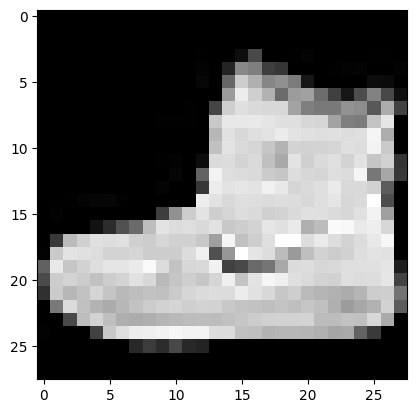

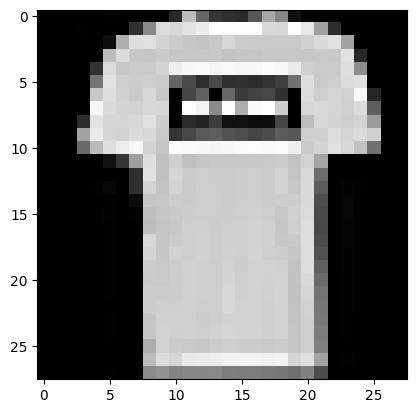

Labela prve slike: 9
Labela druge slike: 0


In [21]:
# Uzeti prve dve slike iz trening skupa

img1 = train_dataset[0][0]
img2 = train_dataset[1][0]

# Prikazati prve dve slike

plt.imshow(img1.squeeze(), cmap="gray")
plt.show()

plt.imshow(img2.squeeze(), cmap="gray")
plt.show()

# Prikazati labele za prve dve slike

print("Labela prve slike:", train_dataset[0][1])
print("Labela druge slike:", train_dataset[1][1])


## 5. Podela trening skupa na trening i validacioni deo

In [22]:
# Podeliti trening skup na trening i validacioni deo

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(
    train_dataset,
    [train_size, val_size],
    generator=split_generator
)

print("Broj primera u trening skupu:", len(train_data))
print("Broj primera u validacionom skupu:", len(val_data))

Broj primera u trening skupu: 48000
Broj primera u validacionom skupu: 12000


## 6. Kreiranje batch-eva pomoću DataLoader-a

In [23]:
# Formirati DataLoader objekte za trening, validacioni i test skup
# Koristiti batch_size = 32

train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_data,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

# Prikazati broj batch-eva u trening, validacionom i test skupu

print("Broj batch-eva u trening skupu:", len(train_loader))
print("Broj batch-eva u validacionom skupu:", len(val_loader))
print("Broj batch-eva u test skupu:", len(test_loader))


Broj batch-eva u trening skupu: 1500
Broj batch-eva u validacionom skupu: 375
Broj batch-eva u test skupu: 313


## 7. Definisanje modela pomoću nn.Module

In [24]:
# Definisati klasu višeslojne feedforward neuronske mreže

class FeedForwardNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)

    def forward(self, x):

        x = x.reshape(x.shape[0], -1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))

        x = self.fc4(x)

        return x


## 8. Kreiranje instance modela

In [25]:
# Kreirati instancu prethodno definisanog modela

model = FeedForwardNet()

# Prikazati arhitekturu modela

print(model)


FeedForwardNet(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (fc4): Linear(in_features=64, out_features=10, bias=True)
)


## 9. Definisanje modela pomoću Sequential

In [26]:
# Definisati istu arhitekturu modela pomoću nn.Sequential

model_seq = nn.Sequential(

    nn.Flatten(),

    nn.Linear(28*28, 256),
    nn.ReLU(),

    nn.Linear(256, 128),
    nn.ReLU(),

    nn.Linear(128, 64),
    nn.ReLU(),

    nn.Linear(64, 10)
)

# Prikazati arhitekturu Sequential modela

print(model_seq)


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=128, bias=True)
  (4): ReLU()
  (5): Linear(in_features=128, out_features=64, bias=True)
  (6): ReLU()
  (7): Linear(in_features=64, out_features=10, bias=True)
)


## 10. Uvođenje Dropout regularizacije

In [27]:
# Definisati model sa Dropout regularizacijom pomoću nn.Module

class FeedForwardNetDropout(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)

        self.dropout = nn.Dropout(0.2)

    def forward(self, x):

        x = x.view(x.shape[0], -1)

        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.dropout(F.relu(self.fc3(x)))

        x = self.fc4(x)

        return x

In [28]:
# Definisati model sa Dropout regularizacijom pomoću nn.Sequential

model_seq_dropout = nn.Sequential(

    nn.Flatten(),

    nn.Linear(28*28, 256),
    nn.ReLU(),
    nn.Dropout(0.2),

    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(0.2),

    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(0.2),

    nn.Linear(64, 10)
)

## 11. Definisanje funkcije greške i Adam optimizatora

In [29]:
# Za trening koristiti Sequential model sa Dropout regularizacijom

model = model_seq_dropout

# Definisati funkciju greške CrossEntropyLoss

criterion = nn.CrossEntropyLoss()

# Definisati Adam optimizacioni algoritam

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

## 12. Trening modela uz validacioni skup i čuvanje najboljeg modela

In [30]:
# Istrenirati model i pratiti train i validation grešku
# Čuvati model sa najmanjim validation loss

num_epochs = 20

best_val_loss = float("inf")
best_model_path = "best_feedforward_model.pth"

best_epoch = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    model.train()
    train_loss = 0

    for images, labels in train_loader:

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():

        for images, labels in val_loader:
            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_path)

        best_epoch = epoch + 1

print(f"Sačuvan najbolji model epoha: {best_epoch}")

Sačuvan najbolji model epoha: 12


In [31]:
# Prikazati tabelarno train i validation loss po epohama
results = pd.DataFrame({
    "Epoha": range(1, num_epochs+1),
    "Train loss": train_losses,
    "Validation loss": val_losses
})

print(results)

    Epoha  Train loss  Validation loss
0       1    0.626179         0.454221
1       2    0.438059         0.389049
2       3    0.400678         0.367793
3       4    0.375051         0.361816
4       5    0.355465         0.364363
5       6    0.343997         0.346291
6       7    0.335907         0.343635
7       8    0.318858         0.336088
8       9    0.314733         0.321677
9      10    0.306604         0.345945
10     11    0.298798         0.319878
11     12    0.295450         0.315423
12     13    0.287680         0.327385
13     14    0.283832         0.336195
14     15    0.278942         0.332466
15     16    0.274524         0.319084
16     17    0.267407         0.325865
17     18    0.266908         0.355719
18     19    0.263231         0.328106
19     20    0.262143         0.331938


## 13. Učitavanje najboljeg modela



In [32]:
# Učitati najbolje sačuvane parametre modela

model.load_state_dict(torch.load(best_model_path))

<All keys matched successfully>

## 14. Predikcije modela nad test skupom

In [33]:
# Izračunati predikcije najboljeg modela nad test skupom
# Sačuvati stvarne i predikovane klase

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        _, preds = torch.max(outputs, dim=1)

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Prikazati broj predikcija

print("Broj predikcija:", len(all_preds))


Broj predikcija: 10000


## 15. Matrica konfuzije

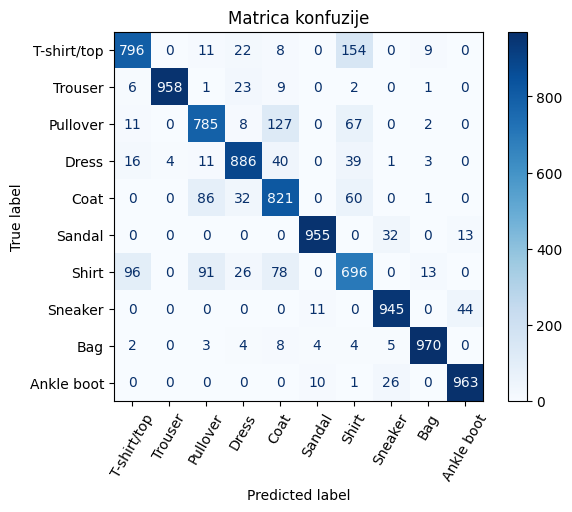

In [34]:
# Izračunati i prikazati matricu konfuzije

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=60)

plt.title("Matrica konfuzije")
plt.show()


## 16. Evaluacija modela

In [35]:
# Izračunati accuracy i classification report za najbolji učitani model

accuracy = accuracy_score(all_labels, all_preds)
print("Tačnost modela:", round(accuracy, 4))

print(classification_report(all_labels, all_preds))


Tačnost modela: 0.8775
              precision    recall  f1-score   support

           0       0.86      0.80      0.83      1000
           1       1.00      0.96      0.98      1000
           2       0.79      0.79      0.79      1000
           3       0.89      0.89      0.89      1000
           4       0.75      0.82      0.79      1000
           5       0.97      0.95      0.96      1000
           6       0.68      0.70      0.69      1000
           7       0.94      0.94      0.94      1000
           8       0.97      0.97      0.97      1000
           9       0.94      0.96      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000

